# Chapter 4

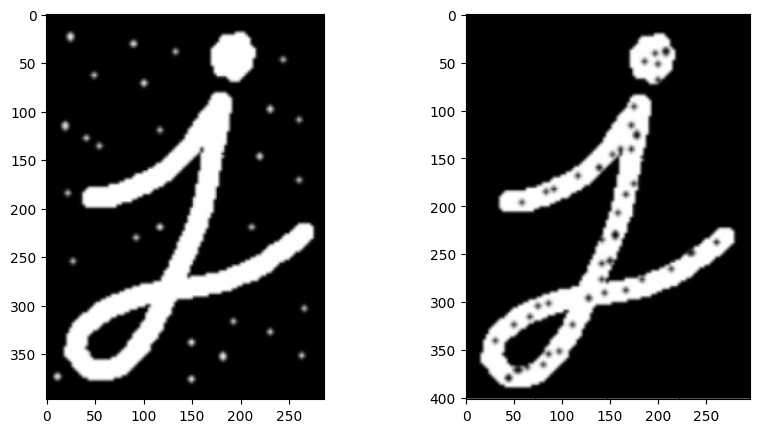

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow( cv2.imread("images/morph_dot.jpg", 0), cmap='gray' )
axes[1].imshow( cv2.imread("images/morph_hole.jpg", 0), cmap='gray' )
plt.show()


## Erosion

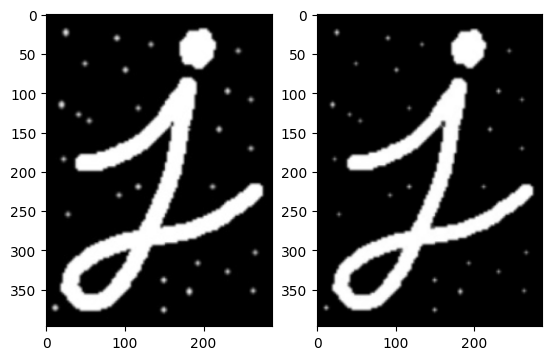

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

src = cv2.imread("images/morph_dot.jpg", 0)


H = src.shape[0]
W = src.shape[1]

mask_size = 3
padding = mask_size // 2

dst = np.zeros_like(src).astype(np.uint8)

for h in range(padding, H-padding):
    for w in range(padding, W-padding):
        roi = src[h-padding : h-padding+mask_size , w-padding : w-padding+mask_size]
        dst[h,w] = np.min(roi)


plt.subplot(1,2,1 )
plt.imshow(src, cmap = 'gray')
plt.subplot(1,2,2)
plt.imshow(dst , cmap = 'gray')



## Dilation

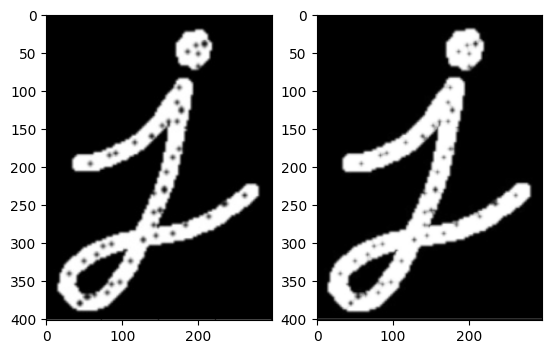

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

src = cv2.imread("images/morph_hole.jpg", 0)

H = src.shape[0]
W = src.shape[1]

mask_size = 3
padding = mask_size // 2

dst = np.zeros_like(src).astype(np.uint8)

for h in range(padding, H-padding):
    for w in range(padding, W-padding):
        roi = src[h-padding : h-padding+mask_size , w-padding : w-padding+mask_size]
        dst[h,w] = np.max(roi)


plt.subplot(1,2,1 )
plt.imshow(src, cmap = 'gray')
plt.subplot(1,2,2)
plt.imshow(dst , cmap = 'gray')

## Repeated Erosion and Dilation

In [ ]:
def erode_dil(src, mask_size, type):
    
    H = src.shape[0]
    W = src.shape[1]

    dst = np.zeros_like(src).astype(np.uint8)


    for h in range(1, H-1):
        for w in range(1, W-1):
            roi = src[h-1 : h-1+mask_size , w-1 : w-1+mask_size]

            if type == 'erode':
                dst[h,w] = np.min(roi)
            elif type == 'dil':
                dst[h,w] = np.max(roi)
    
    return dst
    

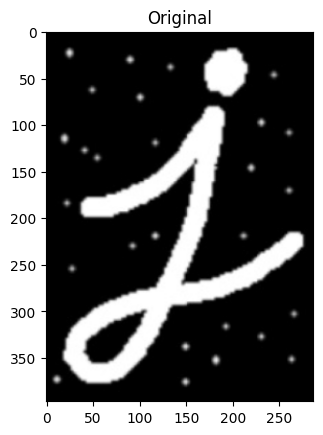

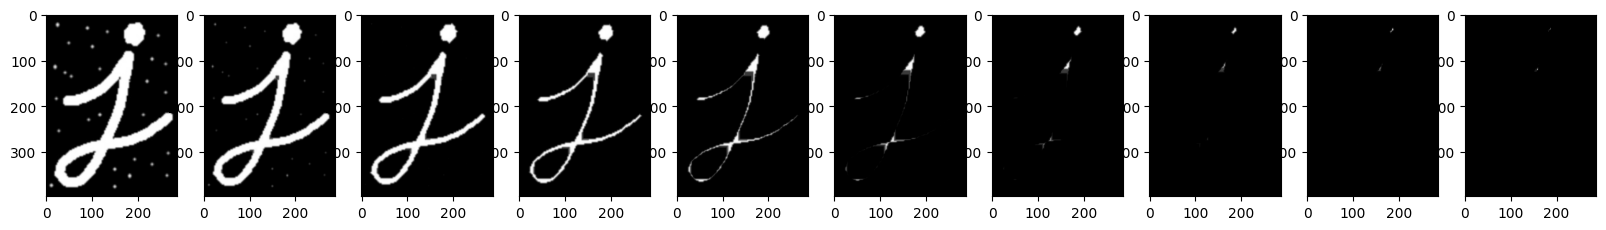

In [43]:
src = cv2.imread("images/morph_dot.jpg", 0)
results = [src]
title = 'Original'
plt.title(title)
plt.imshow(results[0], cmap='gray')
plt.show()


repeat = 10
mask_size = 5

fig, axes = plt.subplots(1, repeat, figsize=(20, 5))

for i in range(repeat):
    dst = erode_dil(src, mask_size, 'erode')
    results.append(dst)
    src = dst
    
    axes[i].imshow(results[i], cmap='gray')

plt.show()


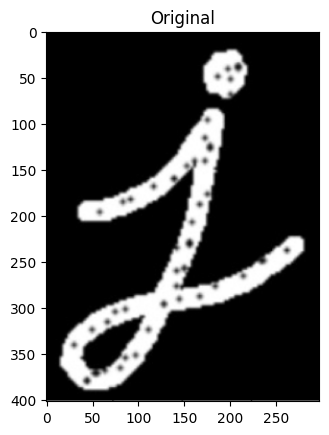

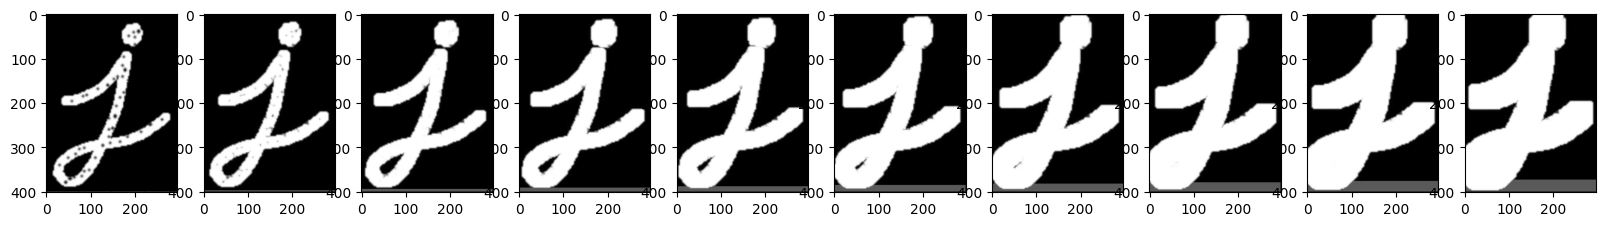

In [39]:
src = cv2.imread("images/morph_hole.jpg", 0)
results = [src]
title = 'Original'
plt.title(title)
plt.imshow(results[0], cmap='gray')
plt.show()

repeat = 10
mask_size = 5

fig, axes = plt.subplots(1, repeat, figsize=(20, 5))

for i in range(repeat):
    dst = erode_dil(src, mask_size, 'dil')
    results.append(dst)
    src = dst
    
    axes[i].imshow(results[i], cmap='gray')

plt.show()



## cv2

In [ ]:
kernel = np.ones((3, 3), np.uint8)

src_erosion = cv2.imread("images/morph_dot.jpg", cv2.IMREAD_GRAYSCALE)
erosion = cv2.erode(src_erosion, kernel, iterations=2)


src_dilation = cv2.imread("images/morph_hole.jpg", cv2.IMREAD_GRAYSCALE)
dilation = cv2.dilate(src_dilation, kernel, iterations=2)


